# RSG - Radar Sequence generator

### At a glance

| | status |
|---|---|
| DiT generates sequences (64×64 sim) | works — 4/4 checks |
| targets on request | works — trajectory-conditioned |
| generated data helps a detector (scarce data) | yes, +0.040 mAP — generator memorises (0.715) |
| simulator ≈ RADIal | scene sim from physics — engineer + fitted variants done |
| DiT at RADIal's grid (512×256) | recipe check running |
| does a generator make sim fidelity matter less? | not tested yet — 64×64 pilot dropped |

1 real radar → 2 sims vs real (Comparison 1) → 3 DiT (Comparison 2) → 4 detector (Comparison 3) → 5 fidelity study → 6 status. App. A: 64×64 sim. App. B: DiT code.

## 0. Setup

In [2]:
import json
import sys
from pathlib import Path

import numpy as np
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)

from src import radial
from src.simulator import generate_sequences
from src.viz import (show_clutter_correlation, show_cuts, show_brightness,
                     show_normalization, show_range_profile, show_rows,
                     show_sequence, show_rd_rows)

## 1. Real radar (RADIal)

- 91 recordings, 77 GHz HD radar, 12 Tx × 16 Rx
- map: 512 range (0.2 m/bin, to 102 m) × 256 Doppler, 5 fps
- red circles = labelled vehicles

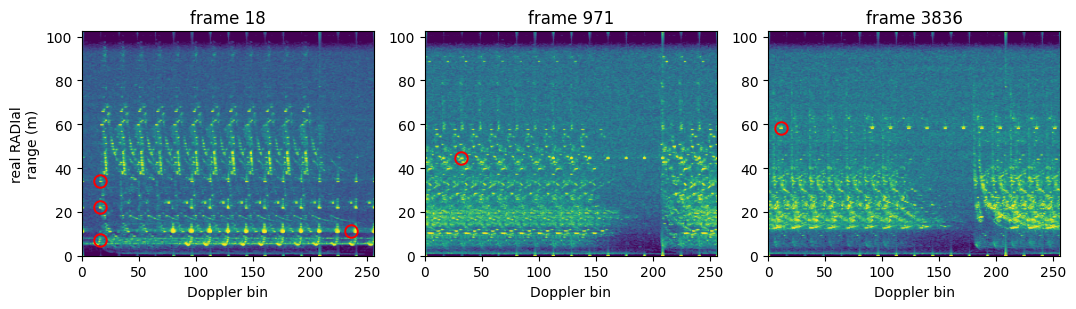

In [2]:
by_frame = radial.read_labels()
frames = sorted(by_frame)
real_ids = (frames[0], frames[400], frames[2000])
real_maps = [radial.power_map(s) for s in real_ids]
show_rd_rows({"real RADIal": real_maps},
             marks={"real RADIal": [radial.targets(s, by_frame) for s in real_ids]},
             col_titles=[f"frame {s}" for s in real_ids])

What's in the maps:
- every return ×12 across Doppler, 16 bins apart → DDMA: 12 Tx fire together, each with its own Doppler code (`rpl.py`)
- dark vertical bands = the 4 empty Tx slots
- textured band ~10–60 m = static world from a moving car → Doppler −v·cos(az)
- near + far range dark = receiver filters (IF high-pass, anti-alias)

### Label columns

- `radar_D_mps` = Doppler **bin index**, not m/s
- `radar_P_db` = linear power, not dB
- range is fine: 0.2 m/bin
- check: labelled vehicles should sit on a peak at their cell

In [3]:
peaks = []
for s in frames[:40]:
    p = radial.power_map(s)
    for rb, db in radial.targets(s, by_frame):
        ri, di = int(round(rb)), int(round(db))
        if 2 <= ri < p.shape[0] - 2 and 2 <= di < p.shape[1] - 2:
            peaks.append(p[ri-2:ri+3, di-2:di+3].max() - np.median(p[ri-2:ri+3, :]))
print(f"{len(peaks)} labelled vehicles: peak above their range ring, "
      f"median {np.median(peaks):.1f} dB (p10 {np.percentile(peaks,10):.1f}, p90 {np.percentile(peaks,90):.1f})")

44 labelled vehicles: peak above their range ring, median 24.6 dB (p10 16.3, p90 31.8)


### Camera + RD

- camera frame for every labelled RD frame (`camera/`, 960×540)
- label boxes are in the 1920×1080 sensor frame → ×0.5
- same number = same vehicle in both views
- RD: circle = the label (Tx0 copy), ticks = its 11 other DDMA copies

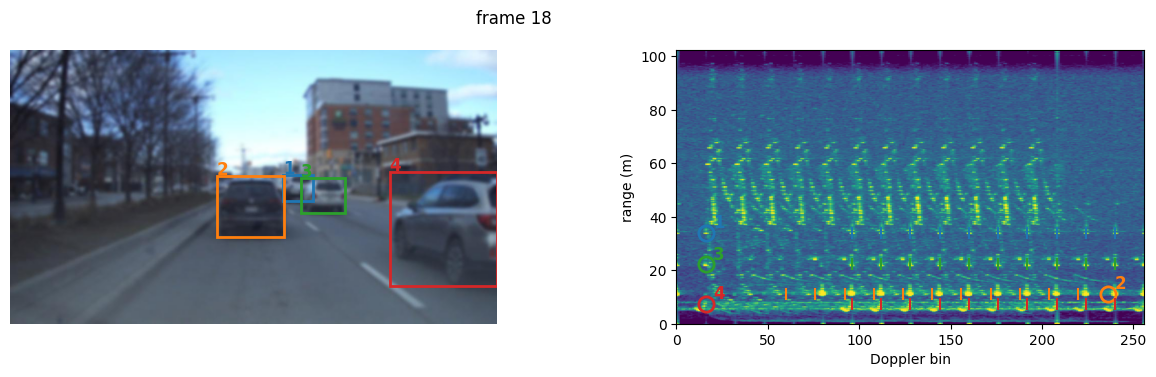

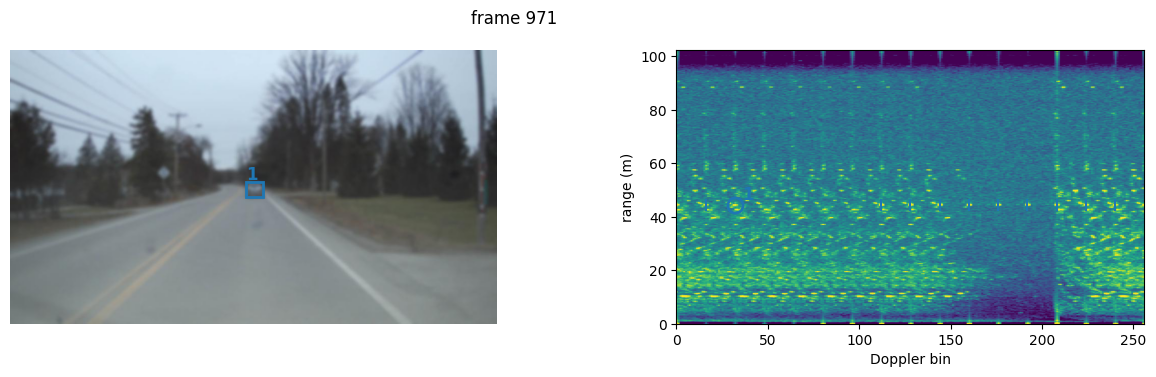

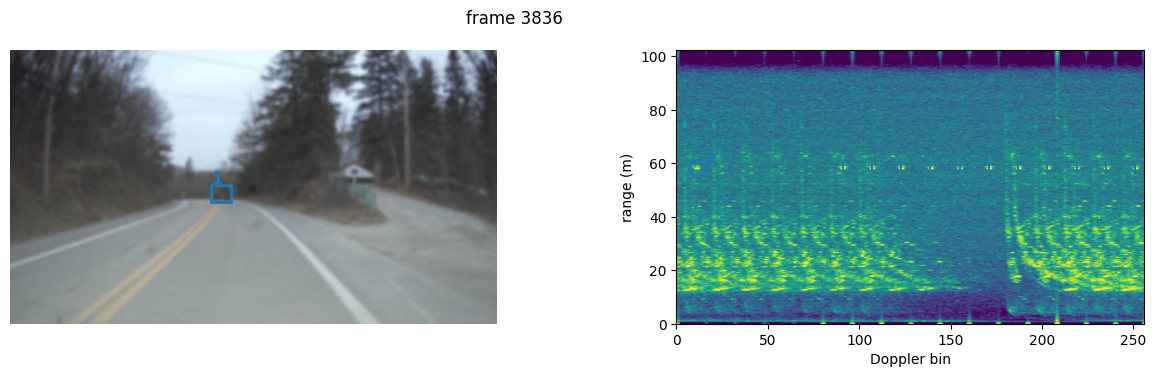

In [ ]:
from src.scene_sim import DDMA_OFFSETS
from src.viz import show_camera_rd

for s in (frames[0], frames[400], frames[2000]):
    show_camera_rd(radial.camera_image(s), radial.power_map(s), radial.vehicles(s, by_frame),
                   title=f"frame {s}", ddma_offsets=DDMA_OFFSETS)

### Scarcity

- sequences need consecutive labelled frames
- split by whole recording (neighbouring frames ≈ duplicates → a frame split tests memorisation)
- split balanced by sequences per recording, pinned: `data/radial/split.json`

In [4]:
split = json.loads((ROOT / "data" / "radial" / "split.json").read_text())
recs = radial.recordings()
print(f"{'split':<7}{'recordings':>11}{'frames':>8}{'16-frame seq':>14}{'8-frame seq':>13}")
for name in ("train", "val", "test"):
    sub = {k: recs[k] for k in split[name]}
    print(f"{name:<7}{len(sub):>11}{sum(len(v) for v in sub.values()):>8}"
          f"{len(radial.sequences(sub, seq_len=16)):>14}{len(radial.sequences(sub, seq_len=8)):>13}")

split   recordings  frames  16-frame seq  8-frame seq
train           67    4544           153          387
val              9    1016            22           74
test            13    1627            44          121


- **219** independent 16-frame sequences in all of RADIal, 153 train (rehearsal had 2,000)
- → moved to 8-frame sequences (387 train)
- → pretraining on simulated data = main defence against memorisation

## 2. Simulators vs real

### 2.1 64×64 simulator (DiT development)

- 64×64, 3 m range bins, a few point targets over statistical clutter
- built to develop the generator, not to look like RADIal
- building blocks: Appendix A

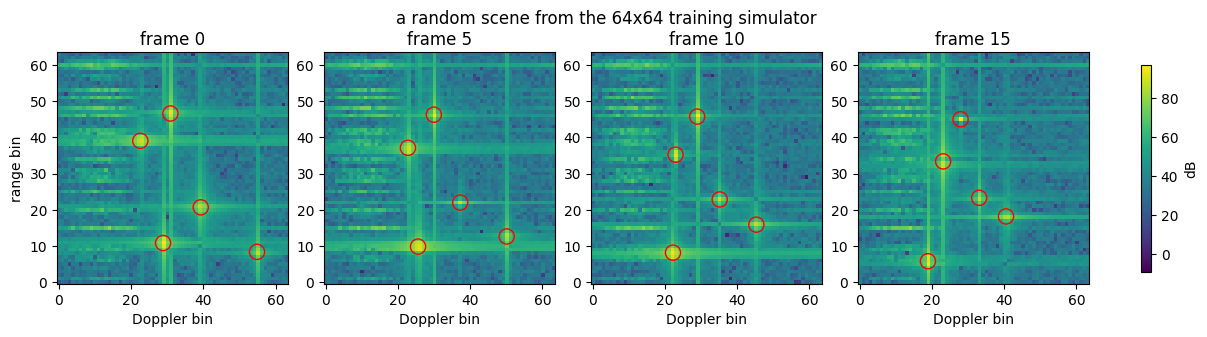

In [5]:
full = generate_sequences(n=8, seed=0)
show_sequence(full, title="a random scene from the 64x64 training simulator")

### 2.2 Comparison 1 — one frame

- rows: real RADIal / scene simulator / first spec simulator
- scene sim (`src/scene_sim.py`): DDMA replication (from `rpl.py`), static world from a moving car, 16-Rx averaging, receiver filters, antenna patterns — nothing tuned to recordings
- first spec sim = old point-target sim on RADIal's grid; kept to show what was missing

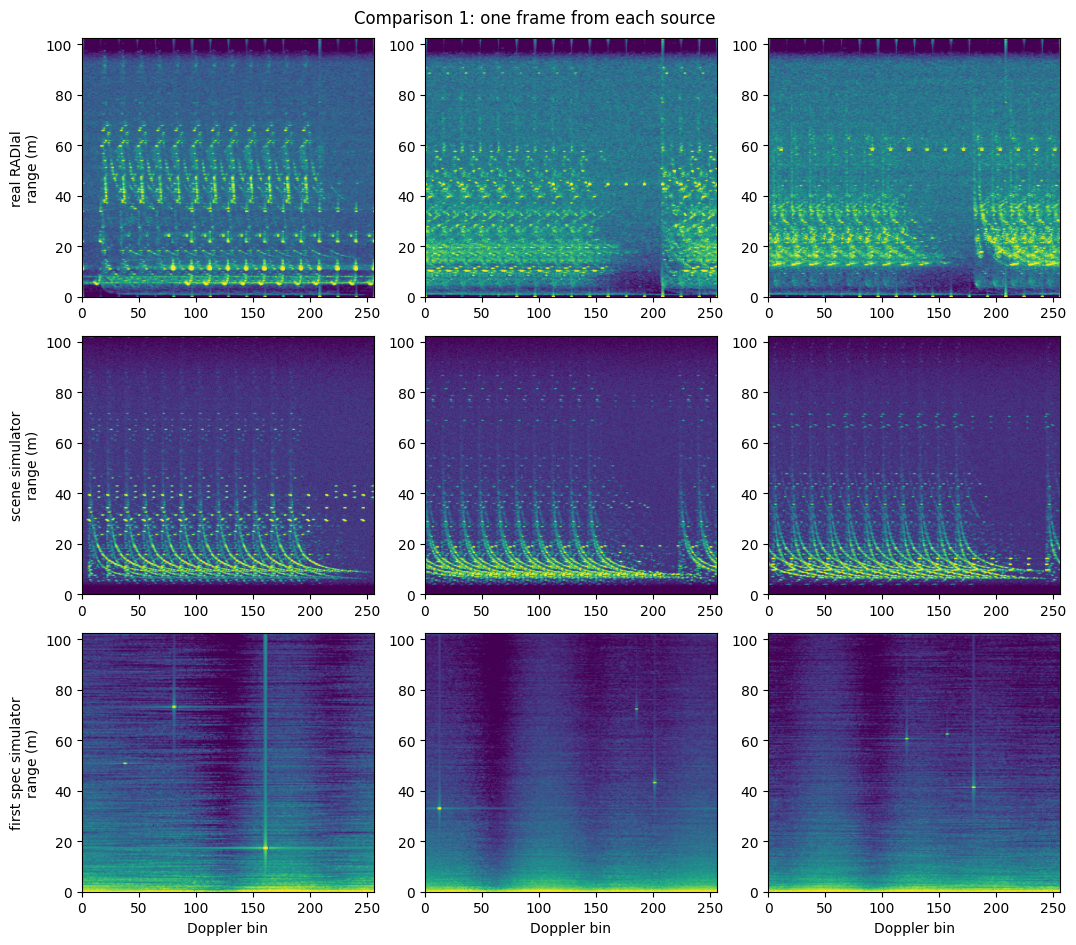

In [6]:
from src.radar_physics import RADIAL_SPEC
from src.scene_sim import SceneSimulator
from src.simulator import spec_simulator

scene = [SceneSimulator(seq_len=1, device=device,
                        generator=torch.Generator().manual_seed(i)).gen_sequence()["x"][0]
         for i in range(3)]
first = []
for i in range(3):
    torch.manual_seed(i)
    first.append(spec_simulator(RADIAL_SPEC, seq_len=1).gen_sequence(n_targets=3)["x"][0])

show_rd_rows({"real RADIal": real_maps, "scene simulator": scene,
              "first spec simulator": first},
             title="Comparison 1: one frame from each source")

### 2.3 Comparison 1 — over time

- 8-frame real sequence (0.2 s apart) vs a simulated one

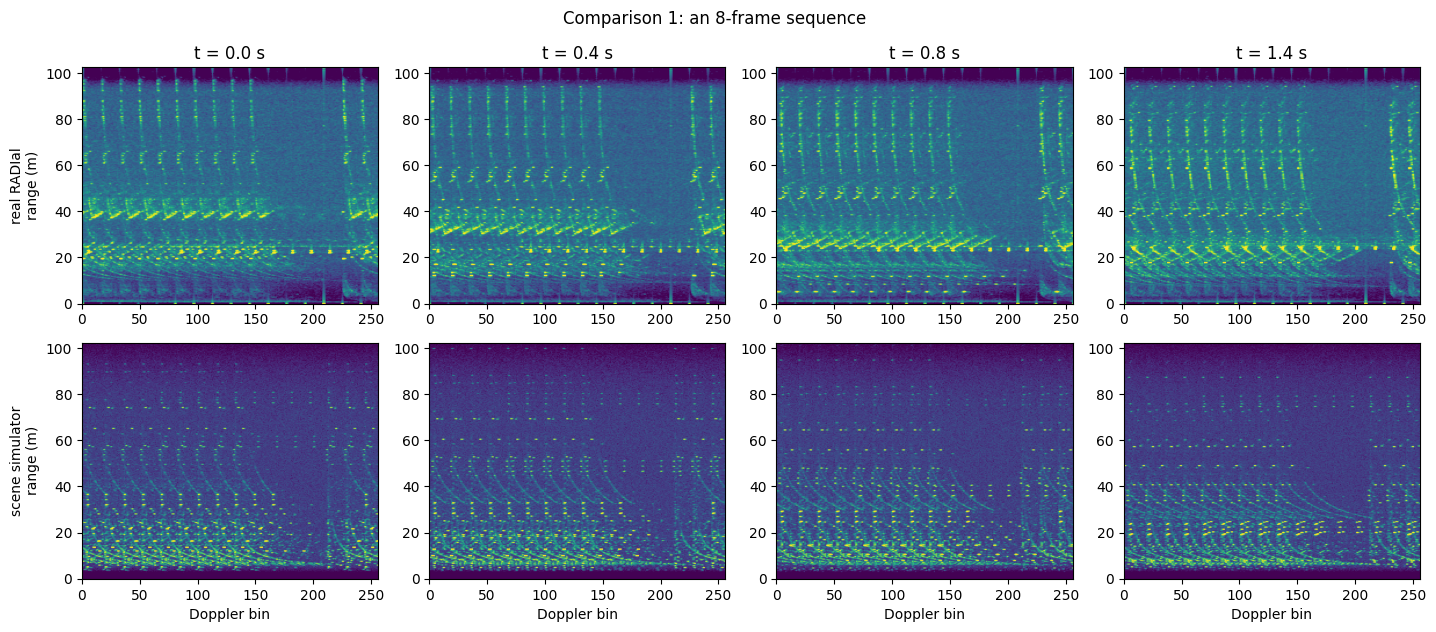

In [7]:
val = {k: recs[k] for k in split["val"]}
name, run = radial.sequences(val, seq_len=8)[0]
real_seq = radial.load_sequence(run)
sim_seq = SceneSimulator(seq_len=8, device=device,
                         generator=torch.Generator().manual_seed(5)).gen_sequence()["x"]
cols = (0, 2, 4, 7)
show_rd_rows({"real RADIal": [real_seq[t] for t in cols],
              "scene simulator": [sim_seq[t] for t in cols]},
             col_titles=[f"t = {t * 0.2:.1f} s" for t in cols],
             title="Comparison 1: an 8-frame sequence")

### 2.4 Comparison 1 — numbers

- background stats; real: 60 frames across the dataset, sims: 30 frames each

In [8]:
real_many = np.stack([radial.power_map(s) for s in frames[::60][:60]])
scene_many = np.stack([SceneSimulator(seq_len=1, device=device,
                       generator=torch.Generator().manual_seed(100 + i)).gen_sequence()["x"][0].numpy()
                       for i in range(30)])
first_many = []
for i in range(30):
    torch.manual_seed(100 + i)
    first_many.append(spec_simulator(RADIAL_SPEC, seq_len=1).gen_sequence(n_targets=3)["x"][0].numpy())
table = {"real": radial.background_stats(real_many),
         "scene sim": radial.background_stats(scene_many),
         "first spec sim": radial.background_stats(np.stack(first_many))}
print(f"{'dB':<28}" + "".join(f"{k:>16}" for k in table))
for stat in table["real"]:
    print(f"{stat:<28}" + "".join(f"{table[k][stat]:>16.1f}" for k in table))

dB                                      real       scene sim  first spec sim
dynamic range (0.1-99.9%)               51.5            54.9           106.8
range-profile spread                    24.2            27.9            80.2
Doppler-profile spread                   2.4             0.6             2.2
near range (0-4 m) vs mid               -6.1           -13.0            39.4
far range (>98 m) vs mid               -16.4            -5.1           -12.0


- scene sim matches real range structure + spread; first spec sim off by tens of dB (targets ~39 dB too prominent)
- still different: real texture = herringbone of short streaks, sim = longer arcs → scene composition
- figures above predate the road types (placeholder composition)

### 2.5 Two simulator variants

- **engineer**: road types from the RADIal README (city / highway / countryside), composition from road knowledge, never tuned to RADIal → honest baseline
- **fitted**: uncertain knobs (surface scattering law, density, ground return, filters, link budget) fitted to RADIal **train** recordings → upper bound on calibration
- distance to real background stats: engineer 1.14, fitted 0.32 (`samples/scene_sim_fit.json`)
- fit drives grazing-angle falloff of rough surfaces to 0 → walls/vegetation ~isotropic at 4 mm → texture reaches ~60 m

## 3. The generator (DiT)

- maps here come from the DiT itself: pure noise → denoised, no simulator
- recipe (`docs/notes/2026-09-15-e3-longer-training.md`): v-prediction, schedule shift 4, no x0 clamp, non-overlapping 8×8 patches, factorized time/space attention (45 M params), EMA, 30 DDIM steps
- developed on the 64×64 sim (2.1); code in Appendix B
- unconditional here → invents its own scene, no target circles, rows show different scenes

In [9]:
from src.dataset import RadarSequenceDataset, held_out_batch
from src.sample import generate

stats = torch.load(ROOT / "data" / "cache" / "stats.pt")

### Comparison 2 — easy regime

- one moving target, no clutter, no noise

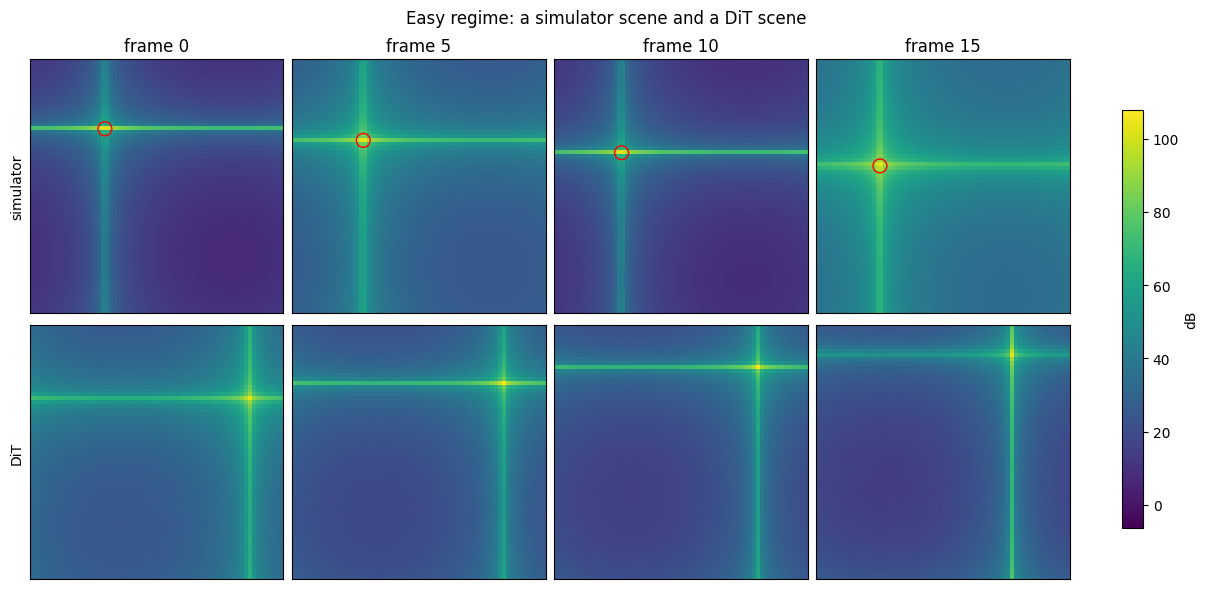

In [10]:
easy_dit = generate(ROOT / "checkpoints" / "e0_standard_bs32" / "last.pt", n_seq=4,
                    device=device, steps=30, weights="ema", seed=1)
easy_sim = generate_sequences(n=4, n_targets=1, target_class="steady", snr_db=20,
                              clutter=False, noise=False, seed=1)
show_rows([easy_sim, {"x": easy_dit}], ["simulator", "DiT"],
          title="Easy regime: a simulator scene and a DiT scene")

### Comparison 2 — full regime

- several targets, classes, clutter, noise

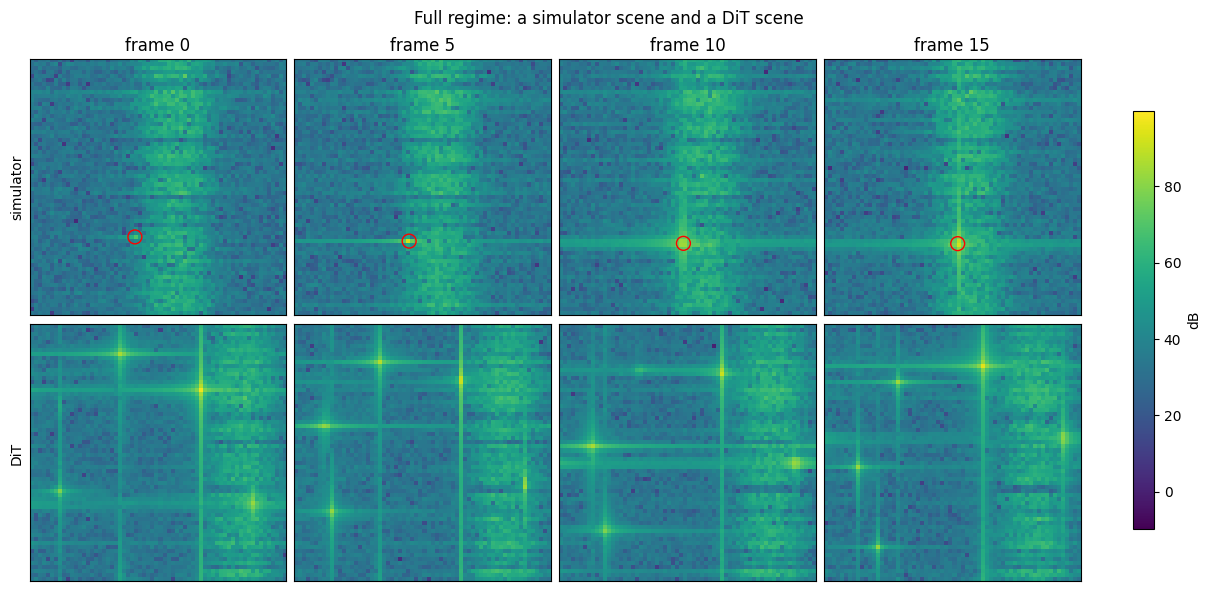

In [11]:
full_ckpt = ROOT / "checkpoints" / "e3_long_bs32" / "last.pt"
full_dit = torch.cat([generate(full_ckpt, n_seq=32, device=device, steps=30, weights="ema", seed=s)
                      for s in (1, 2, 3)])
full_sim = generate_sequences(n=4, seed=1)
show_rows([full_sim, {"x": full_dit}], ["simulator", "DiT"],
          title="Full regime: a simulator scene and a DiT scene")

### Four checks

- 96 DiT sequences vs held-out simulator sequences, same detector + tracker as before
- real vs real = two disjoint sets of 32 held-out sequences = best achievable
- **std** (contrast of normalised map): within 0.1 of real
- **marginal L1** (pixel-brightness mix; 0 same … 2 disjoint): ≤ 0.15
- **target tracks/seq** (detections linked over ≥ 8 of 16 frames): within 15%
- **persistence** (share of linked detections lasting ≥ 13/16 frames; low = flicker): within 25%

In [12]:
from src.eval.metrics import evaluate_sequences

full_val = RadarSequenceDataset(ROOT / "data" / "cache", "val")
ref_a, ref_b = held_out_batch(full_val, 32), held_out_batch(full_val, 32, offset=32)
real = evaluate_sequences(ref_a["x"], ref_b["x"])
dit = evaluate_sequences(full_dit, ref_b["x"])
real["std"] = float(((ref_b["x"] - stats["mean"]) / stats["std"]).std())
dit["std"] = float(((full_dit - stats["mean"]) / stats["std"]).std())

checks = {
    "std": abs(dit["std"] - real["std"]) <= 0.1,
    "marginal_l1": dit["marginal_l1"] <= 0.15,
    "n_target_tracks_per_seq": abs(dit["n_target_tracks_per_seq"] - real["n_target_tracks_per_seq"])
                               <= 0.15 * real["n_target_tracks_per_seq"],
    "persistence": abs(dit["persistence"] - real["persistence"]) <= 0.25 * real["persistence"],
}
print(f"{'check':26s} {'real vs real':>12s} {'DiT':>8s}")
for name, ok in checks.items():
    print(f"{name:26s} {real[name]:12.3f} {dit[name]:8.3f}   {'pass' if ok else 'FAIL'}")

check                      real vs real      DiT
std                               1.004    0.939   pass
marginal_l1                       0.065    0.079   pass
n_target_tracks_per_seq           3.094    3.188   pass
persistence                       0.144    0.123   pass


- one draw of 96 → persistence ±0.01 between runs; 6 seeds: `samples/e3_long_scores.json`, all 4 pass
- fidelity to the simulator, not to real radar
- gaps: persistence ≈ 0.12 vs 0.14, motion slightly jerkier

## 4. Does generated data help a detector?

- all simulated → exact ground truth
- generator saw 2,000 sequences, rendered 8,000 labelled
- detector must find each target + name its class
- rules fixed before the run: informative only if 20k real beats 2k by > seed spread; synthetic helps only if it clears the same bar

### Comparison 3 — detector trained on different data

In [13]:
report = json.loads((ROOT / "samples" / "detector_class_augmentation.json").read_text())
names = {"real_n": "2,000 real", "real_n_synth": "2,000 real + 8,000 generated",
         "synth_only": "8,000 generated only", "real_full": "20,000 real (ceiling)"}
print(f"{'trained on':<32}{'mean mAP':>10}{'seed range':>12}")
for key, arm in report["arms"].items():
    print(f"{names[key]:<32}{arm['mean']:>10.3f}{arm['range']:>12.3f}")
rule = report["rule"]
print(f"\ngain from generated data: {rule['gain']:+.3f} (bar {rule['gain_bar']:.3f}) -> helps: {rule['helps']}")

mem = json.loads((ROOT / "samples" / "memorization_n2000.json").read_text())
print(f"memorisation ratio {mem['ratio_training_over_heldout']:.3f} (below 0.8 = copying) -> memorising: {mem['memorising']}")

trained on                        mean mAP  seed range
2,000 real                           0.665       0.018
2,000 real + 8,000 generated         0.705       0.006
8,000 generated only                 0.689       0.025
20,000 real (ceiling)                0.760       0.052

gain from generated data: +0.040 (bar 0.018) -> helps: True
memorisation ratio 0.715 (below 0.8 = copying) -> memorising: True


- generated data helps: +0.040 mAP (2× the bar), ~40% of the way to the 20k ceiling
- generated only (0.689) beat 2k real (0.665)
- but the generator memorises (ratio 0.715 < 0.8) → result flagged
- lesson for real data: scarcity → memorisation

## 5. Fidelity study

- simulator fidelity = the variable
- per simulator: pretrain DiT on it → fine-tune on a little real data → detector trained with:
  - **A** real only
  - **B** real + raw simulator data
  - **D** real + DiT data
- result = interaction: B should drop as the sim gets worse; D flat → a generator makes sim fidelity matter less; D tracks B → idea dead

### 64×64 pilot (dropped)

- sim-to-sim rehearsal on the 64×64 sim, mismatch = dB of target brightness
- first run invalid: EMA 0.9999 after 7.5k steps still ~47% random init → generated targets on their labels 8–16% of the time; fixed (raw warm start, short EMA, hit-rate gate)
- dropped: old simulator unusable for this task
- next: the same study on RADIal with the engineer + fitted scene sims

In [14]:
from src.viz import show_fidelity_curve

path = ROOT / "samples" / "fidelity_pilot.json"
if not path.exists():
    print("no results: the 64x64 pilot was stopped")
else:
    pilot = json.loads(path.read_text())
    done = sorted(pilot["deltas"], key=float)
    arms = {"real": [], "real_sim": [], "real_synth": []}
    print(f"{'mismatch dB':>12}{'A real':>9}{'B raw sim':>11}{'D DiT':>9}{'D - B':>8}{'hit rate':>10}")
    for key in done:
        d = pilot["deltas"][key]
        a = d["detector"]["arms"]
        for n in arms:
            arms[n].append(a[n]["mean"])
        print(f"{key:>12}{a['real']['mean']:>9.3f}{a['real_sim']['mean']:>11.3f}{a['real_synth']['mean']:>9.3f}"
              f"{a['real_synth']['mean'] - a['real_sim']['mean']:>+8.3f}{d.get('synthetic_hit_rate', float('nan')):>10.2f}")
    if len(done) > 1:
        show_fidelity_curve([float(k) for k in done], arms)

no results: the 64x64 pilot was stopped


## 6. Status

- **done:** DiT generates sequences, 4/4 checks; trajectory-conditioned version; generated data helps a detector with scarce data (memorisation flag)
- **done:** RADIal decoded + split; scene sim from physics; engineer + fitted variants; 8-frame 512×256 training caches
- **running:** recipe check at 512×256 — schedule shift 16 vs 4, patch 16 vs 32
- **next:** pretrain on each variant → fine-tune on RADIal → detector arms A / B / D on RADIal test
- **idea:** one DiT across radars (CARRADA, RADDet), conditioned on the radar spec — after the RADIal result

## Appendix A — 64×64 simulator

### 0. `generate_sequences`

- one call → labelled RD sequences
- unset args = random, drawn like the training data
- scalar = every target; list = per target (its length sets n_targets)

| parameter | meaning | if left out |
|---|---|---|
| `n` | number of sequences | 1 |
| `seq_len` | frames per sequence, 0.5 s apart | 16 |
| `n_targets` | targets per sequence (1–5) | random |
| `target_class` | `"steady"`, `"swerling1"` (power fluctuates every frame) or `"extended"` (spread over 3 range bins) | random |
| `snr_db` | target strength in dB | random, −5 to 10 dB |
| `clutter`, `noise` | background clutter and receiver noise, on or off | on |
| `rho`, `nu` | clutter frame-to-frame correlation (0–1) and spikiness | random |
| `r0`, `v0`, `a` | initial range (m), radial velocity (m/s), acceleration (m/s²) | random, kept inside the map |
| `seed` | fixes the random draws | not fixed |

returns (dict of tensors):
- `x`: dB, `(n, seq_len, 64, 64)` = (seq, frame, range, Doppler)
- `traj`: true (range bin, Doppler bin) per frame, `(n, 5, seq_len, 2)`
- `v0`, `acc`, `cls`: `(n, 5)`
- `env`: `[CNR, SCNR, rho]` per sequence
- `n_targets`: real slots out of 5; the rest is zero padding

- each step below changes one thing; red circles = true positions

### 1. Constant velocity

- one target, constant speed, no clutter, no noise

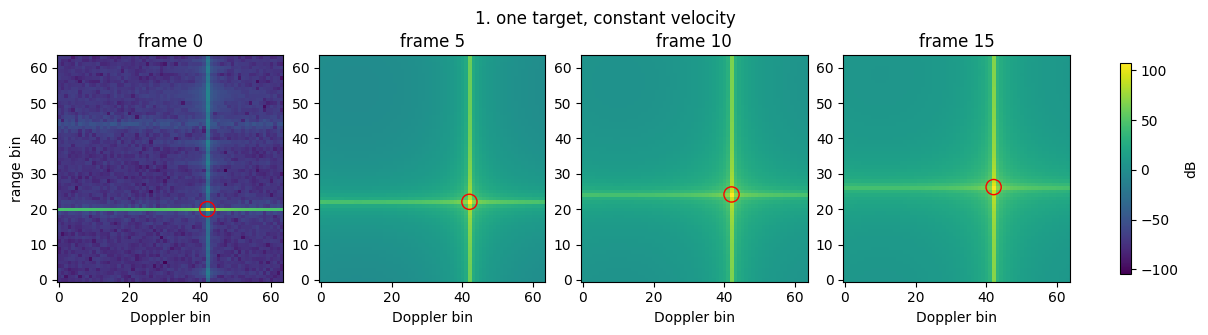

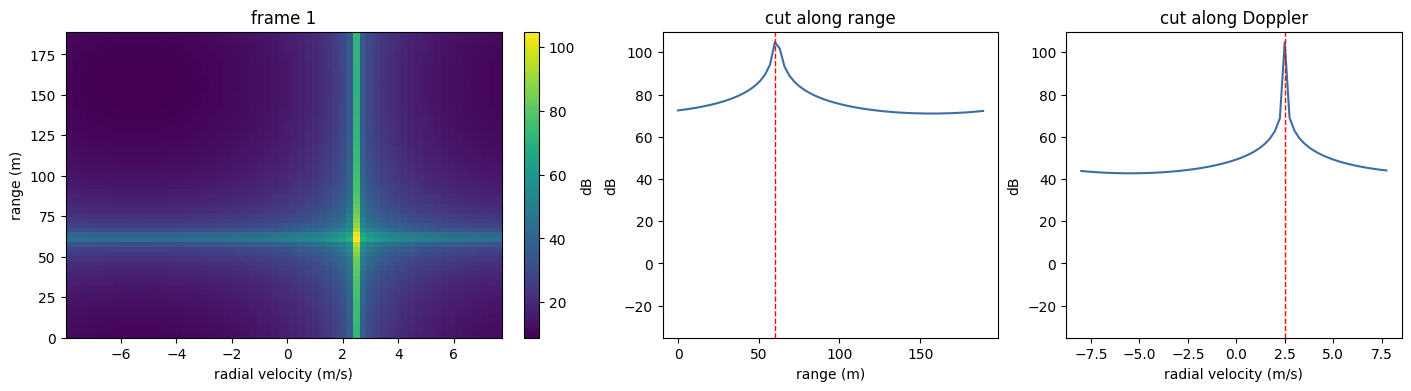

In [15]:
# one static target on an empty map
# static = generate_sequences(n_targets=1, target_class="steady", snr_db=20, clutter=False, noise=False, r0=90, v0=0, a=0, seed=0)
# show_sequence(static, frames=(0,), title="one static target")

constant = generate_sequences(n_targets=1, target_class="steady", snr_db=20, clutter=False, noise=False, r0=60, v0=2.5, a=0, seed=0)
show_sequence(constant, title="1. one target, constant velocity")
show_cuts(constant, t=1)

### 2. Acceleration

- same target, accelerating → Doppler drifts, track bends

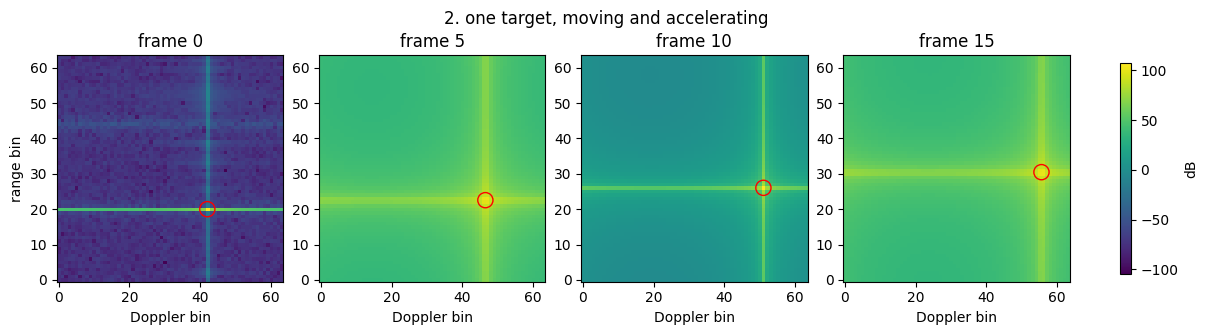

In [16]:
moving = generate_sequences(n_targets=1, target_class="steady", snr_db=20, clutter=False, noise=False, r0=60, v0=2.5, a=0.45, seed=0)
show_sequence(moving, title="2. one target, moving and accelerating")

### 3. Receiver noise

- accelerating target without / with receiver noise, one colour scale

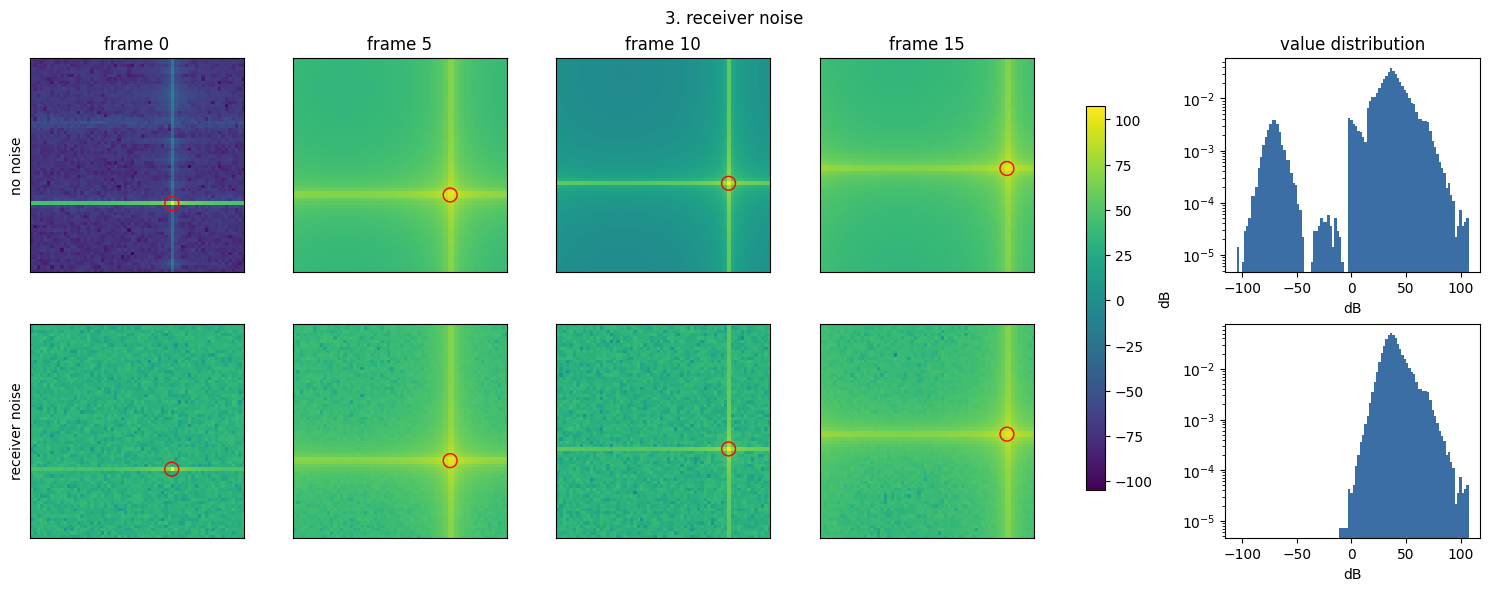

In [17]:
noisy = generate_sequences(n_targets=1, target_class="steady", snr_db=20, clutter=False, noise=True, r0=60, v0=2.5, a=0.45, seed=0)
show_rows([moving, noisy], ["no noise", "receiver noise"], title="3. receiver noise", hist=True)

### 4. Clutter

- rows: smooth (`nu=1.5`) vs spiky (`nu=0.1`) clutter; band + stripes fixed across frames
- `rho` only changes the fine speckle (invisible) → measured: clutter signal's frame-to-frame correlation (blue) follows `rho`; the dB map's (orange) stays high because band/stripes don't move

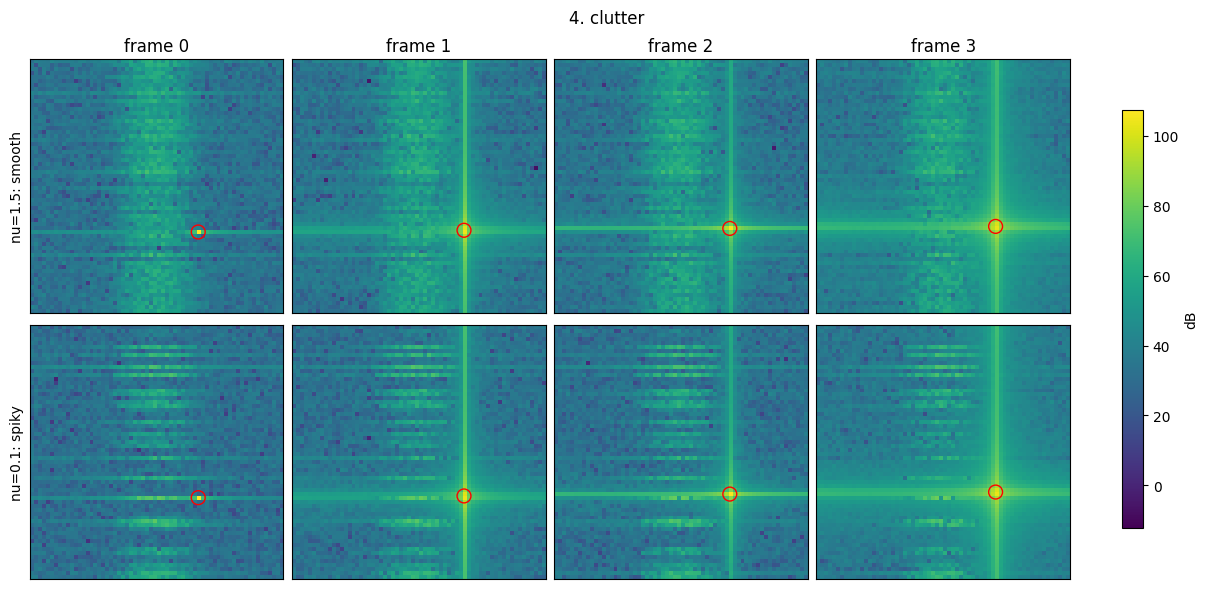

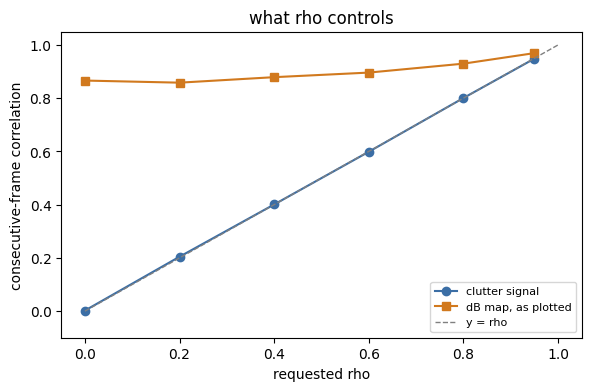

In [18]:
smooth = generate_sequences(n_targets=1, target_class="steady", snr_db=20, rho=0.95, nu=1.5, r0=60, v0=2.5, a=0.45, seed=0)
spiky = generate_sequences(n_targets=1, target_class="steady", snr_db=20, rho=0.95, nu=0.1, r0=60, v0=2.5, a=0.45, seed=0)
show_rows([smooth, spiky], ["nu=1.5: smooth", "nu=0.1: spiky"], frames=(0, 1, 2, 3), title="4. clutter")
show_clutter_correlation()

### 5. Target strength

- same clutter ×3, band around Doppler bin 31
- rows: weak target outside the band / same weak target inside / strong target inside
- inside the band the weak target drops ~36 → 23 dB above background; the strong one stands out again

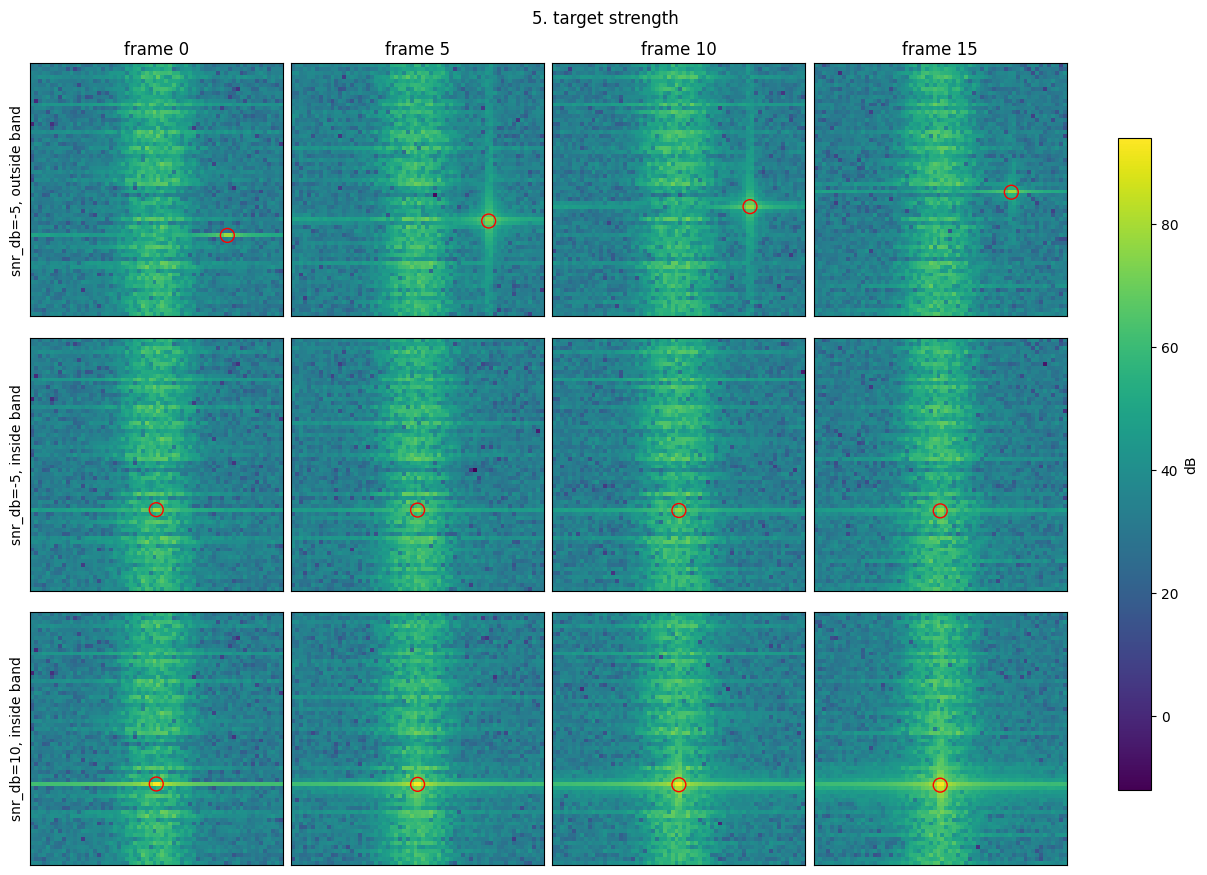

In [19]:
weak_outside = generate_sequences(n_targets=1, target_class="steady", snr_db=-5, rho=0.5, nu=1.0, r0=60, v0=4.37, a=0, seed=0)
weak_inside = generate_sequences(n_targets=1, target_class="steady", snr_db=-5, rho=0.5, nu=1.0, r0=60, v0=-0.12, a=0, seed=0)
strong_inside = generate_sequences(n_targets=1, target_class="steady", snr_db=10, rho=0.5, nu=1.0, r0=60, v0=-0.12, a=0, seed=0)
show_rows([weak_outside, weak_inside, strong_inside], ["snr_db=-5, outside band", "snr_db=-5, inside band", "snr_db=10, inside band"], title="5. target strength")

### 6. Target classes

- rows: steady, Swerling-1, extended, same motion
- peak brightness: steady/extended dip a little between bins; Swerling-1 jumps frame to frame
- range profile (static target, empty map): point = 1 range bin, extended = 3

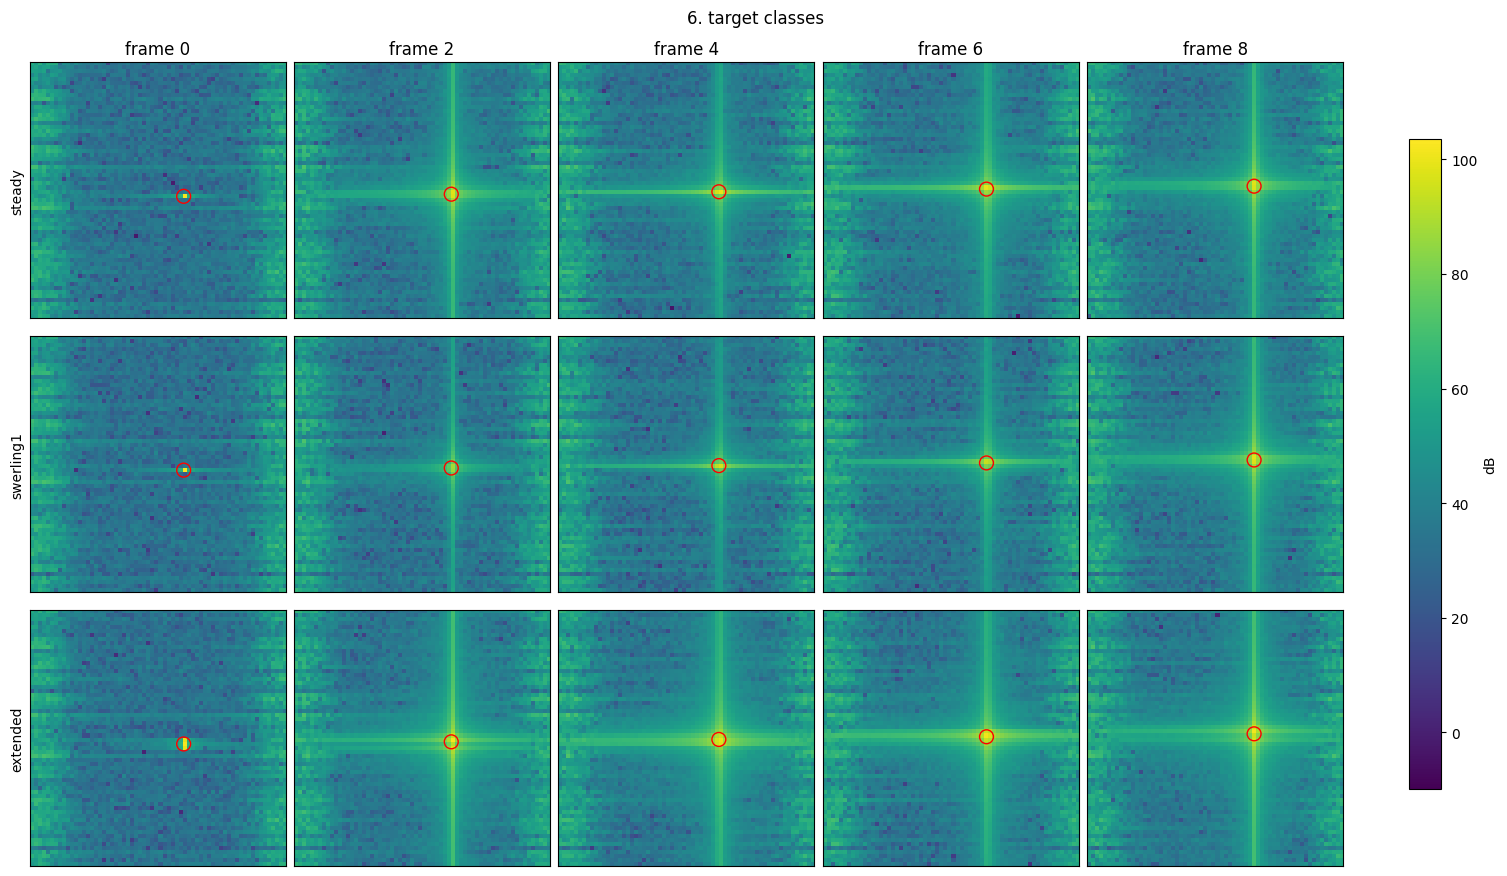

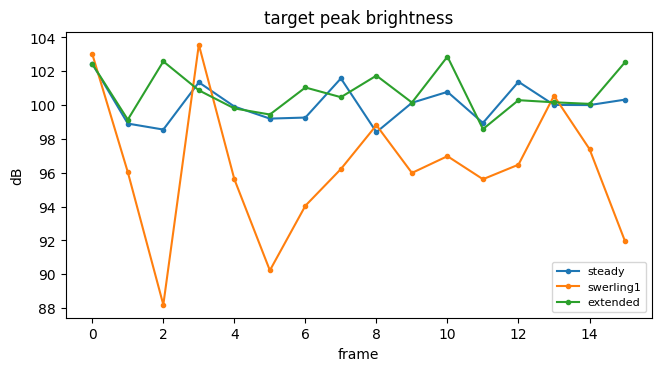

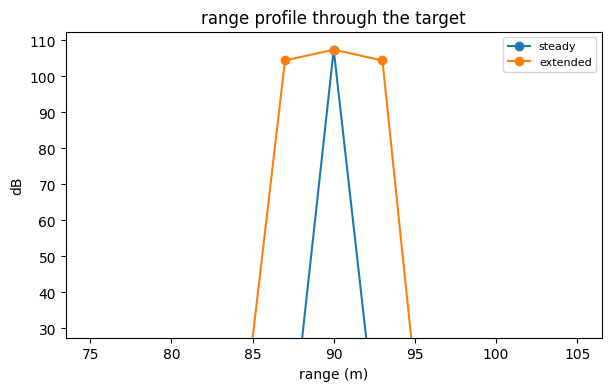

In [20]:
classes = [generate_sequences(n_targets=1, target_class=c, snr_db=15, rho=0.5, nu=1.0, r0=90, v0=1.5, a=0.2, seed=3) for c in ("steady", "swerling1", "extended")]
show_rows(classes, ["steady", "swerling1", "extended"], frames=(0, 2, 4, 6, 8), title="6. target classes")
show_brightness(classes, ["steady", "swerling1", "extended"])
point = generate_sequences(n_targets=1, target_class="steady", snr_db=20, clutter=False, noise=False, r0=90, v0=0, a=0, seed=0)
extended = generate_sequences(n_targets=1, target_class="extended", snr_db=20, clutter=False, noise=False, r0=90, v0=0, a=0, seed=0)
show_range_profile([point, extended], ["steady", "extended"])

### 7. Several targets

- three targets starting at 40, 90, 150 m; random speeds + accelerations

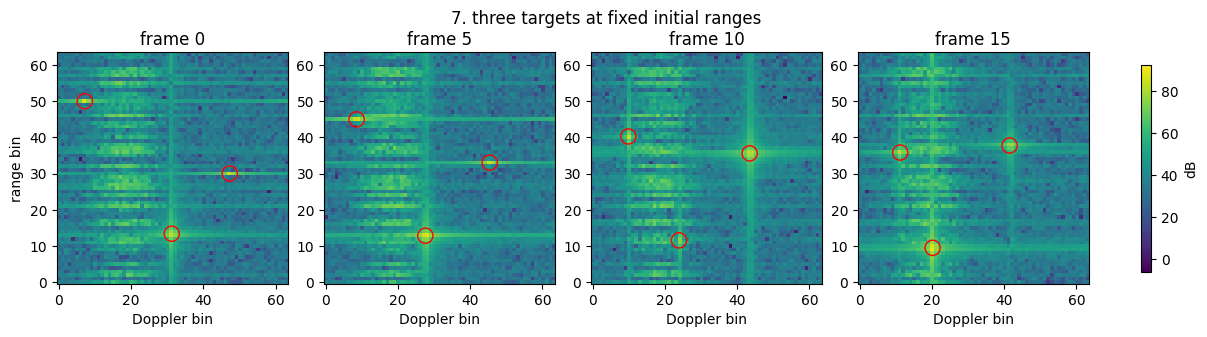

In [21]:
three = generate_sequences(n=8, r0=[40, 90, 150], seed=0)
show_sequence(three, title="7. three targets at fixed initial ranges")

### 8. Full training distribution

- in section 2.1

### Normalization

- diffusion adds unit-size noise → data must be on the same scale
- $x_{\text{norm}} = (x_{\text{dB}} - \text{mean}) / \text{std}$
- mean, std: two numbers, computed once over all pixels of the 20k training sequences
- same pair for train / val / generated → a dB value always maps to the same number (strong target stays stronger)
- back to dB: `x_dB = x_norm × std + mean` (`denormalize`, `src/dataset.py`)

#### 1. The two numbers

- saved when the training set was built

In [22]:
stats = torch.load(ROOT / "data" / "cache" / "stats.pt")
print(f"mean = {stats['mean']:.2f} dB, std = {stats['std']:.2f} dB")


mean = 41.48 dB, std = 11.07 dB


#### 2. Before and after

- 64 random training sequences, normalised with those two numbers
- left, raw dB: black = mean, grey = ±1 std
- right, normalised: bulk ~0, spread ~1 (same scale as the diffusion noise); targets = thin right tail; dashed = where the brightest 1% (~2.5) and 0.1% (~4) start → the tail the generator struggles with

after normalising: mean 0.01, std 1.00


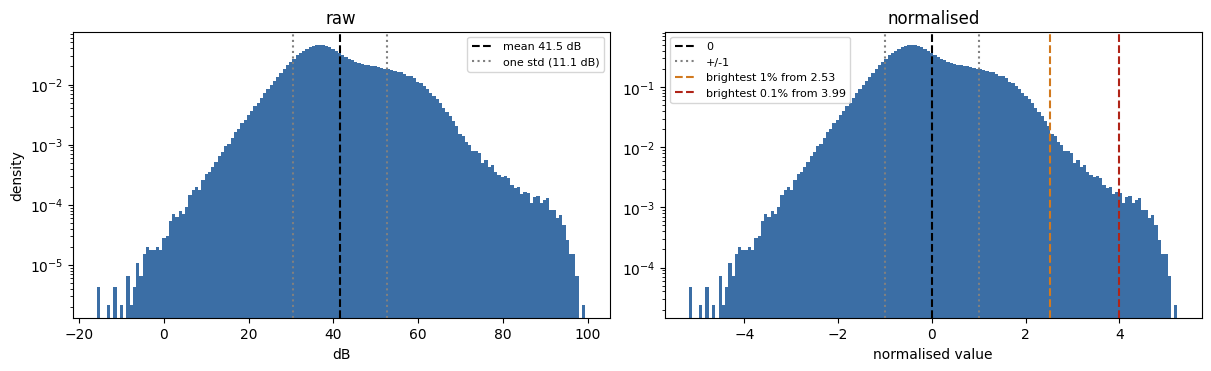

In [23]:
batch = generate_sequences(n=64, seed=0)
x_norm = (batch["x"] - stats["mean"]) / stats["std"]
print(f"after normalising: mean {x_norm.mean():.2f}, std {x_norm.std():.2f}")
show_normalization(batch["x"], stats)


## Appendix B — DiT code

- whole model + sampler written out; same computation as `src/dit.py` + `src/diffusion.py` for the working config (8×8 patches, factorized attention, v-prediction, shift 4)
- last cell: trained weights → this code, output checked against `src`

#### 1. Patches

- 64×64 frame → 64 non-overlapping 8×8 patches → one token each

In [24]:
import math
import torch.nn as nn
import torch.nn.functional as F

PATCH = 8


def to_patches(x):
    """(B, L, 64, 64) -> (B, L, 64 tokens, 64 values): 8x8 patches, row by row."""
    B, L, N, K = x.shape
    x = x.reshape(B, L, N // PATCH, PATCH, K // PATCH, PATCH)
    return x.permute(0, 1, 2, 4, 3, 5).reshape(B, L, (N // PATCH) * (K // PATCH), PATCH * PATCH)


def from_patches(tokens, N=64, K=64):
    """Inverse of to_patches."""
    B, L = tokens.shape[:2]
    x = tokens.reshape(B, L, N // PATCH, K // PATCH, PATCH, PATCH)
    return x.permute(0, 1, 2, 4, 3, 5).reshape(B, L, N, K)

#### 2. Timestep embedding

- t → sinusoidal features → MLP in the model → conditioning vector for every block

In [25]:
def timestep_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
    args = t.float()[:, None] * freqs[None]
    return torch.cat([torch.cos(args), torch.sin(args)], dim=-1)

#### 3. Attention

- standard multi-head self-attention
- weights stay in `nn.MultiheadAttention` (checkpoints load); compute = PyTorch fused kernel

In [26]:
def attend(attn, h):
    """Self-attention over the sequence axis of h: (batch, tokens, width)."""
    B, T, d = h.shape
    q, k, v = F.linear(h, attn.in_proj_weight, attn.in_proj_bias).chunk(3, dim=-1)
    q, k, v = (u.view(B, T, attn.num_heads, d // attn.num_heads).transpose(1, 2) for u in (q, k, v))
    out = F.scaled_dot_product_attention(q, k, v)
    return attn.out_proj(out.transpose(1, 2).reshape(B, T, d))

#### 4. Block: time → space → MLP

- time attention: across the 16 frames at each patch position → a patch follows its content
- space attention: across the 64 patches of a frame → the frame agrees on one scene
- each sub-layer shifted / scaled / gated by the noise-level vector (adaLN-Zero: gates start at 0 → untrained block = identity)

In [27]:
class FactorizedBlock(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        self.norm_t = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
        self.attn_t = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm_s = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
        self.attn_s = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
        self.mlp = nn.Sequential(nn.Linear(dim, 4 * dim), nn.GELU(), nn.Linear(4 * dim, dim))
        self.adaLN = nn.Sequential(nn.SiLU(), nn.Linear(dim, 9 * dim))   # shift, scale, gate for 3 sub-layers
        nn.init.zeros_(self.adaLN[1].weight)
        nn.init.zeros_(self.adaLN[1].bias)

    def forward(self, z, c):
        B, L, P, d = z.shape   # batch, frames, patches per frame, width
        sh_t, sc_t, g_t, sh_s, sc_s, g_s, sh_m, sc_m, g_m = self.adaLN(c)[:, None, None].chunk(9, dim=-1)
        # time: each patch position attends over the 16 frames
        h = (self.norm_t(z) * (1 + sc_t) + sh_t).permute(0, 2, 1, 3).reshape(B * P, L, d)
        z = z + g_t * attend(self.attn_t, h).reshape(B, P, L, d).permute(0, 2, 1, 3)
        # space: the 64 patches of each frame attend to each other
        h = (self.norm_s(z) * (1 + sc_s) + sh_s).reshape(B * L, P, d)
        z = z + g_s * attend(self.attn_s, h).reshape(B, L, P, d)
        # MLP on every token
        return z + g_m * self.mlp(self.norm2(z) * (1 + sc_m) + sh_m)

#### 5. Full model

- patches → tokens + learned position (in frame, in time) → 12 blocks → one output patch per token → maps
- output = v (v-prediction), a known mix of noise and clean map (see 6)

In [28]:
class DiT(nn.Module):
    def __init__(self, dim=384, depth=12, heads=6, frames=16, n_patches=64):
        super().__init__()
        self.dim = dim
        self.proj = nn.Linear(PATCH * PATCH, dim)
        self.spatial_pos = nn.Parameter(torch.zeros(1, 1, n_patches, dim))
        self.temporal_pos = nn.Parameter(torch.zeros(1, frames, 1, dim))
        self.t_mlp = nn.Sequential(nn.Linear(dim, dim), nn.SiLU(), nn.Linear(dim, dim))
        self.blocks = nn.ModuleList(FactorizedBlock(dim, heads) for _ in range(depth))
        self.final_norm = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
        self.final_adaLN = nn.Sequential(nn.SiLU(), nn.Linear(dim, 2 * dim))
        self.out = nn.Linear(dim, PATCH * PATCH)

    def forward(self, x, t):
        z = self.proj(to_patches(x)) + self.spatial_pos + self.temporal_pos
        c = self.t_mlp(timestep_embedding(t, self.dim))
        for block in self.blocks:
            z = block(z, c)
        shift, scale = self.final_adaLN(c)[:, None, None].chunk(2, dim=-1)
        return from_patches(self.out(self.final_norm(z) * (1 + scale) + shift))


print(f"parameters: {sum(p.numel() for p in DiT().parameters()) / 1e6:.1f} M")

parameters: 45.0 M


#### 6. Schedule + training objective

- `abar[t]` = share of the clean map surviving at level t
- cosine schedule shifted by s = 4 → every level's SNR ÷ 16: a 16×64×64 sequence is so redundant its scene shows at very low SNR → need more noisy levels
- training: noise a clean normalised sequence to a random level, predict v

In [29]:
def alphas_bar(T=1000, shift=4.0):
    t = torch.arange(T + 1, dtype=torch.float64) / T
    f = torch.cos((t + 0.008) / 1.008 * math.pi / 2) ** 2
    betas = torch.clamp(1 - (f[1:] / f[0]) / (f[:-1] / f[0]), max=0.999)
    abar = torch.cumprod(1 - betas, dim=0)
    return (abar / (abar + shift ** 2 * (1 - abar))).float()   # SNR / shift^2


def training_loss(model, x0, abar):
    """x0: clean normalised sequences (B, 16, 64, 64)."""
    t = torch.randint(0, len(abar), (x0.shape[0],))
    ab = abar[t].view(-1, 1, 1, 1)
    eps = torch.randn_like(x0)
    xt = ab.sqrt() * x0 + (1 - ab).sqrt() * eps          # noisy input
    v = ab.sqrt() * eps - (1 - ab).sqrt() * x0           # what the model must output
    return F.mse_loss(model(xt, t), v)

#### 7. Sampling (DDIM, 30 steps)

- start from pure noise; each step: predict v → estimate x0 and noise → move to the next, less noisy level
- last step returns x0

In [30]:
@torch.no_grad()
def ddim_sample(model, abar, n, steps=30, seed=None, frames=16, device="cpu"):
    if seed is not None:
        torch.manual_seed(seed)
    x = torch.randn(n, frames, 64, 64, device=device)
    ts = torch.linspace(len(abar) - 1, 0, steps).long()
    abar = abar.to(device)
    for i, t in enumerate(ts):
        ab = abar[t]
        v = model(x, t.repeat(n).to(device))
        x0 = ab.sqrt() * x - (1 - ab).sqrt() * v         # clean-map estimate
        eps = (1 - ab).sqrt() * x + ab.sqrt() * v        # noise estimate
        if i == steps - 1:
            return x0
        ab_next = abar[ts[i + 1]]
        x = ab_next.sqrt() * x0 + (1 - ab_next).sqrt() * eps

#### 8. Check: this code = the trained DiT

- full-regime EMA weights → notebook `DiT` (all names must match)
- compare with `src`: one forward pass, then a whole 30-step sample from the same starting noise

In [31]:
from src.train import build_model
from src.sample import generate

ckpt_path = ROOT / "checkpoints" / "e3_long_bs32" / "last.pt"
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
dit = DiT()
dit.load_state_dict(ckpt["ema_model"], strict=True)
dit.eval()
reference = build_model(ckpt["config"], torch.device("cpu"))
reference.load_state_dict(ckpt["ema_model"])
reference.eval()

x, t = torch.randn(2, 16, 64, 64), torch.tensor([100, 800])
with torch.no_grad():
    print("one forward pass, max difference:", float((dit(x, t) - reference(x, t)).abs().max()))

ours = ddim_sample(dit, alphas_bar(), n=1, seed=7) * stats["std"] + stats["mean"]
theirs = generate(ckpt_path, n_seq=1, device=torch.device("cpu"), steps=30, weights="ema", seed=7)
print("30-step sample, max difference (dB):", float((ours - theirs).abs().max()))

one forward pass, max difference: 0.0


30-step sample, max difference (dB): 0.0
